In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import datetime 


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Running on {device}")
#Data as Tensor
labels = torch.load("training_labels.pt",weights_only=True)
images = torch.load("training_tensor.pt",weights_only=True)
print("done")

Running on mps
done


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3150.3052..59.33565].


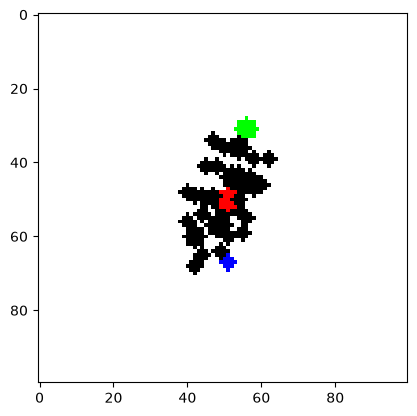

In [34]:
from matplotlib import pyplot as plt
plt.imshow(images[10,7,:,:,:].permute(1, 2, 0)*255)

In [3]:
print(labels.shape)
print(images.shape)

torch.Size([11705, 20])
torch.Size([11705, 20, 3, 100, 100])


In [4]:
mean = images.mean(dim=(0,1,3,4))
std = images.std(dim=(0,1,3,4))
images = (images - mean[None,None,:,None,None]) / std[None,None,:,None,None] 


labels = labels[:,0]  #one label per molecule
labels = labels.long()

Ligand_train = torch.utils.data.TensorDataset(images, labels)
train_loader_Ligand = torch.utils.data.DataLoader(Ligand_train, batch_size = 64, shuffle = False)

In [16]:
#STAGE 2 : Creating the Model

class Net(nn.Module):     
    def __init__(self):   
        super().__init__() 
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)       
        self.act1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)                               
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)    
        self.act2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)     
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)    
        self.act3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(p=0.6)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)                         
        self.act4 = nn.ReLU()
        self.fc2 = nn.Linear(128, 2)   
    

    def forward(self, x):  
                
        batch_size, rotations, C, H, W = x.shape
        x = x.view(batch_size * rotations, C, H, W)
        x = self.pool1(self.act1(self.conv1(x)))
        x = self.pool2(self.act2(self.conv2(x)))
        x = self.pool3(self.act3(self.conv3(x)))
        x = x.view(-1, 64 * 12 * 12)
        x = self.act4(self.fc1(x))
        x = x.view(batch_size, rotations, -1)

        x = x.max(dim=1)[0]

        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [6]:
#Loading Validation Data

#Data as Tensor
labels_val = torch.load("validation_labels.pt")
images_val = torch.load("validation_tensor.pt")


images_val = (images_val - mean[None,:,None,None]) / std[None,:,None,None] 

labels_val = labels_val.long()

Ligand_val = torch.utils.data.TensorDataset(images_val, labels_val)
val_loader_Ligand = torch.utils.data.DataLoader(Ligand_val, batch_size = 64, shuffle = False)


In [14]:
imgs, labels = next(iter(val_loader_Ligand))

print(imgs.shape)
print(labels.shape)



torch.Size([64, 20, 3, 100, 100])
torch.Size([64, 20])


In [15]:
from sklearn.metrics import roc_auc_score

def validate2(model,train_loader, val_loader):

    model.eval()

    true_labels = []
    pred_probs = []

    with torch.no_grad():

        for imgs, labels in val_loader:
   

            imgs = imgs.to(device)
            labels = labels.to(device)


            outputs = model(imgs)

            probs = torch.softmax(outputs, dim=1)[:,1]

            pred_probs.extend(probs.cpu().numpy())

            true_labels.extend(labels[:,0].cpu().numpy())

    auc = roc_auc_score(true_labels, pred_probs)

    print(f"Validation AUROC = {auc:.4f}")

    model.train()

In [ ]:
#STAGE 3 : TRAINING LOOP

#Defining Training Loop
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    
    for epoch in range(1, n_epochs + 1):  
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_train = loss_train + loss.item() 


        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {}'.format(
                datetime.datetime.now(), epoch,
                loss_train / len(train_loader)))  
        if epoch == 1  or   epoch % 5 == 0:
            validate2(model, train_loader_Ligand, val_loader_Ligand)
            torch.save(model.state_dict(), "ligand_model4.pt")
    
            
    
      

#Define Variables
train_loader = train_loader_Ligand
model4 = Net().to(device) 
print(device)
optimizer = optim.SGD(model4.parameters(), lr=1e-2) 
weights = torch.tensor([1.0, 40.0], dtype=torch.float32).to(device)
loss_fn = nn.CrossEntropyLoss(weight=weights)  

#Run Training Loop
training_loop(n_epochs = 50,
    optimizer = optimizer,
    model = model4,
    loss_fn = loss_fn,
    train_loader = train_loader_Ligand)


mps
2026-07-21 11:56:31.919358 Epoch 1, Training loss 0.08792632946262996
Validation AUROC = 0.7272
Validation AUROC = 0.8244
2026-07-21 12:11:28.890000 Epoch 10, Training loss 0.08992929097018179
Validation AUROC = 0.8355


KeyboardInterrupt: 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-12.354138..0.23268883].


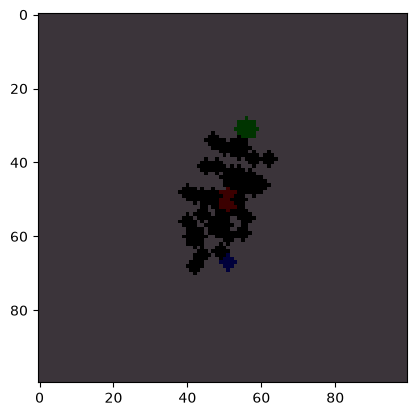

In [31]:
from matplotlib import pyplot as plt
plt.imshow(images[10,7,:,:,:].permute(1, 2, 0))

In [18]:
#Loading Model
model4 = Net().to(device)
model4.load_state_dict(torch.load("ligand_model4.pt"))
model4.eval()


FileNotFoundError: [Errno 2] No such file or directory: 'ligand_model4.pt'

In [ ]:
model4.eval()

predicted_ligands = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader_Ligand:
        outputs = model4(imgs)
        predicted = outputs.argmax(dim=1)

        predicted_ligands += (predicted == 1).sum().item()
        total += len(labels)

print("Predicted ligands:", predicted_ligands)
print("Total images:", total)